**Generating Dataset:**

Completly synthetic

In [6]:
from faker import Faker
import random
import time
import numpy as np


def generate_dataset():
    fake = Faker()
    data = []
    NUM_SAMPLES = 50000

    # --- VOCABULARY ---
    # High Value Signals
    high_exts = [".pem", ".key", ".kdbx", ".xlsx", ".pdf", ".docx", ".wallet", ".sql"]
    high_keywords = [
        "password",
        "budget",
        "secret",
        "salary",
        "invoice",
        "prod_key",
        "backup",
        "private",
        "ssh",
    ]
    high_paths = [
        "C:\\Users\\Admin\\Desktop",
        "C:\\Users\\CEO\\Documents",
        "D:\\Backups",
    ]

    # Junk Signals (Custom lists are still good for System files)
    junk_exts = [".dll", ".sys", ".tmp", ".cache", ".png", ".ico", ".dat", ".bin"]
    junk_paths = [
        "C:\\Windows\\System32",
        "C:\\Program Files",
        "C:\\Users\\Appdata\\Local\\Temp",
    ]
    print("Generating rows...")

    for _ in range(NUM_SAMPLES):
        # 1. Decide Class (95% Junk, 5% Value)
        is_target = random.choices([True, False], weights=[5, 95], k=1)[0]

        if is_target:
            # --- HIGH VALUE GENERATION ---
            # Use Custom Lists to ensure Strong Signal
            base_name = random.choice(high_keywords)
            # Add randomness so they aren't duplicates
            name = f"{base_name}_{random.randint(10,99)}"
            ext = random.choice(high_exts)
            path = random.choice(high_paths)

            # Valuable files are usually somewhat recent
            days_old = random.randint(0, 100)
            label = 1.0

        else:
            # --- JUNK GENERATION (Hybrid) ---
            # Flip a coin: 50% "Professional Noise" (Faker), 50% "System Junk" (Custom)

            if random.random() > 0.5:
                # Option A: Faker (Realism)
                # Generates: 'marketing_plan.pdf', 'logo.png'
                name = fake.file_name(category=None, extension="")
                ext = "." + fake.file_extension()
                # Faker paths look like: /usr/local/bin... we need to fake Windows paths
                path = f"C:\\Users\\{fake.user_name()}\\Downloads"

            else:
                # Option B: System Junk
                name = f"sys_{random.randint(1000,9999)}"
                ext = random.choice(junk_exts)
                path = random.choice(junk_paths)

            days_old = random.randint(0, 2000)
            label = 0.0

        # 2. Shared Metadata Logic
        current_time = time.time()
        mod_time = int(current_time - (days_old * 24 * 3600))

        # Calculate size based on extension
        if ext in [".pem", ".key", ".txt"]:
            size = random.randint(100, 4000)  # Small keys
        else:
            size = random.randint(10000, 50 * 1024 * 1024)  # Big binaries/docs

        data.append(
            {
                "filename": name + ext,
                "path": path,
                "extension": ext,
                "size_bytes": size,
                "mod_time_unix": mod_time,
                "label": label,
            }
        )

    return pd.DataFrame(data)

In [ ]:
import os
import pandas as pd

# Define your local project path ('.' means the current folder where the notebook is saved)
PROJECT_PATH = "../.."
DATASET_PATH = os.path.join(PROJECT_PATH, "datasets/training_data.csv")

# Verify the path
print(f"Project folder set to: {os.path.abspath(PROJECT_PATH)}")
print(f"Dataset path set to: {os.path.abspath(DATASET_PATH)}")

# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    print("⚠️ Dataset not found. Generating new data (This takes time)...")

    df = generate_dataset()

    # --- SAVE TO DRIVE ---
    print(f"Saving to {DATASET_PATH}...")
    df.to_csv(DATASET_PATH, index=False)
    print("✅ Saved!")

Saving/loading Dataset:

In [2]:
DATASET_PATH = "../datasets"

Pre-processing the dataset:

In [36]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

df = pd.read_csv(f"{DATASET_PATH}/merged/final_training_dataset_ready.csv")

valuable_exts = [
        # IT / Secrets
        ".pem", ".key", ".kdbx", ".p12", ".ovpn", ".private", ".wallet", 
        ".asc", ".gpg", ".sql", ".env", ".json", ".yml", ".yaml", 
        # Finance
        ".xlsx", ".xls", ".csv", ".pdf", 
        # HR
        ".docx", ".doc", ".rtf"
    ]

# todo: recency score - figure out a good balance
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (90 * 24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])

# todo: change to more nuanced scoring/hashing
df["valuable_ext"] = (
    df["extension"]
    .isin(valuable_exts)
    .astype(int)
)

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(3, 3),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

numerical_features = df[["recency_score", "size_logged", "valuable_ext"]].values
X = hstack([numerical_features, filename_vectors, path_vectors])
y = df["label_finance"].values

In [37]:
df.to_csv("1.csv", index=False)

In [38]:
# Convert the first 5 rows to a dense array
X_sample_dense = X.toarray()

# To make it more readable, let's put it into a DataFrame, although this is only for display purposes
# as X itself is a sparse matrix.
num_numerical_features = numerical_features.shape[1]
num_filename_features = filename_vectors.shape[1]
num_path_features = path_vectors.shape[1]

# Create column names for better readability
column_names = (
    ["recency_score", "size_logged", "valuable_ext"]
    + [f"filename_hash_{i}" for i in range(num_filename_features)]
    + [f"path_hash_{i}" for i in range(num_path_features)]
)

# Display the sample as a DataFrame
X_sample_df = pd.DataFrame(X_sample_dense, columns=column_names)
display(X_sample_df.sort_values(by="recency_score", ascending=False))

,recency_score,size_logged,valuable_ext,filename_hash_0,filename_hash_1,filename_hash_2,filename_hash_3,filename_hash_4,filename_hash_5,filename_hash_6,...,path_hash_1014,path_hash_1015,path_hash_1016,path_hash_1017,path_hash_1018,path_hash_1019,path_hash_1020,path_hash_1021,path_hash_1022,path_hash_1023
2446,0.198230,6.987490,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1986,0.198209,9.639457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2271,0.198201,8.622634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1046,0.197716,6.656727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2800,0.197109,10.234983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,0.019756,11.049540,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212,0.018887,12.625072,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39,0.018831,11.742687,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2742,0.018765,12.148147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training:

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Split Data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# 2. Train Model
# Using 'lbfgs' solver is standard. max_iter increased to ensure convergence.
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# 3. Evaluate
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9530988274706867

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       553
           1       0.70      0.64      0.67        44

    accuracy                           0.95       597
   macro avg       0.84      0.81      0.82       597
weighted avg       0.95      0.95      0.95       597



In [40]:
results = pd.DataFrame({
    'filepath': df.loc[idx_test]['path'].values,
    'filename': df.loc[idx_test]['filename'].values,
    'extension': df.loc[idx_test]['extension'].values,
    'size_bytes': df.loc[idx_test]['size_bytes'].values,
    'mod_time_unix': df.loc[idx_test]['mod_time_unix'].values,
    'actual_label': y_test,
    'model_score': y_scores
})

# Sort and slice the results
sorted_results = results.sort_values(by='model_score', ascending=False)
sorted_results

,filepath,filename,extension,size_bytes,mod_time_unix,actual_label,model_score
563,C:\Users\jonathanjones\Documents\GitHub\Bestsw...,edit-product-vendors-taxonomy.php,.php,2752,1680735001,1,0.998405
593,C:\Users\chapmanthomas\Downloads\terraform-mas...,balancer_v1_wrapper.go,.go,8557,1683093841,1,0.994863
215,C:\Users\matthew82\AppData\Local\Packages\Cano...,GetHealthCheckLastFailureReasonResultStaxUnmar...,.java,3038,1693371810,1,0.994409
412,C:\inetpub\wwwroot\google-adwords-api-light\Go...,BudgetBudgetDeliveryMethod.php,.php,716,1688339280,1,0.980028
429,C:\inetpub\wwwroot\ttc2017smartGrids\solutions...,ErpInvoiceLineItemComponentErpInvoiceLineItems...,.cs,2999,1720746662,1,0.979762
...,...,...,...,...,...,...,...
217,Z:\HR\Recruiting\Reqs\2025,03cv734RecotonorderonmotionstodismissCORRECTED...,.docx,125829,1598027474,0,0.000021
384,Z:\HR\Recruiting\Reqs\2025\Citizens,GZS_05252007_1-02cv183_Bangor_v_Citizens.pdf,.pdf,125829,1653474144,0,0.000020
503,Z:\HR\Recruiting\Reqs\2024,JAW_11212006_1-06cv36_AKERSON_V_FALCON.pdf,.pdf,41943,1637667996,0,0.000015
365,Z:\HR\Recruiting\Reqs\2025\Williams,GC_02112003_2-02cv204_Williams_v_SJC.pdf,.pdf,52428,1518012250,0,0.000006


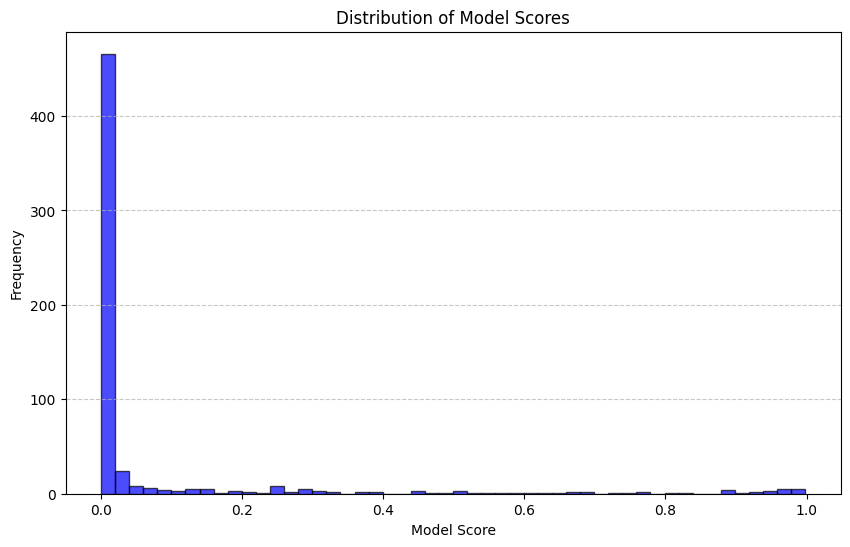

In [41]:
import matplotlib.pyplot as plt

# Plot the distribution of model scores
plt.figure(figsize=(10, 6))
plt.hist(sorted_results['model_score'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Model Scores')
plt.xlabel('Model Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Exporting weights:

In [42]:
import os

def export_model_to_cpp(model, output_path="include/Weights.h"):
    """
    Exports sklearn LogisticRegression weights to a C++ header file.
    """
    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()

    # Format the Content
    cpp_content =f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 
// Weights Count: {len(weights)}

#include <vector>
#include <unordered_set>
#include <string>

const double MODEL_BIAS = {bias:.10f};

const std::vector<double> MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> HIGH_VAL_EXTS = {{
    {', '.join([f'L"{ext}"' for ext in valuable_exts])}}};
"""

    # 3. Ensure Directory Exists and Write
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w") as f:
        f.write(cpp_content)

    print(f"exported weights to: {os.path.abspath(output_path)}")
    print(f"Bias: {bias:.6f}")
    print(f"Num of weights: {len(weights)}")


export_model_to_cpp(model, output_path="../include/ModelWeights.h")

exported weights to: c:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject\include\ModelWeights.h
Bias: -5.539654
Num of weights: 2051
